# 🧠 FSA-CNN v2 — ETRI-Activity3D Action Recognition
### MSc Research Project — Modernised Architecture

**Key improvements over baseline:**
- ✅ Batch Normalisation after every conv block
- ✅ Gradient clipping (clipnorm=1.0) — fixes exploding loss
- ✅ Label smoothing (0.1) — better generalisation
- ✅ LR warmup + cosine decay schedule
- ✅ Mixup augmentation on skeleton streams
- ✅ GELU activations in dense head
- ✅ Reduced dropout 0.8→0.5
- ✅ Depthwise separable conv option (memory efficient)
- ✅ clear_session() each epoch — no GPU memory leak
- ✅ Freeze warmup (no random freeze for first 20 epochs)
- ✅ Robust checkpoint resume

> Set `FSACNNConfig`, then `trainer = FSACNNTrainer(config); trainer.train()`

In [4]:
pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 69.1 MB/s eta 0:00:00:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [2]:
import gc
import math
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, GlobalMaxPooling2D,
    Activation, Dropout, concatenate, Maximum,
    Lambda, Multiply, Add, add, multiply,
    BatchNormalization, DepthwiseConv2D, SeparableConv2D
)
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU        : {len(gpus)} device(s)')
    for gpu in gpus:
        try: tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError: pass
else:
    print('No GPU detected — will run on CPU')

TensorFlow : 2.14.0
NumPy      : 1.26.4
GPU        : 1 device(s)


In [3]:
# ── Metric helpers (pure numpy — no sklearn needed on HPC) ─────────────────
def accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def confusion_matrix(y_true, y_pred, num_classes=55):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def classification_report(y_true, y_pred, class_names):
    lines = [f"{'Class':<12} {'Prec':>8} {'Rec':>8} {'F1':>8} {'N':>7}", '-'*48]
    for i, name in enumerate(class_names):
        tp = np.sum((y_pred==i)&(y_true==i))
        fp = np.sum((y_pred==i)&(y_true!=i))
        fn = np.sum((y_pred!=i)&(y_true==i))
        sup = int(np.sum(y_true==i))
        if sup == 0: continue
        p  = tp/(tp+fp+1e-8)
        r  = tp/(tp+fn+1e-8)
        f1 = 2*p*r/(p+r+1e-8)
        lines.append(f'{name:<12} {p:>8.3f} {r:>8.3f} {f1:>8.3f} {sup:>7}')
    acc = accuracy_score(y_true, y_pred)
    lines.append(f"\n{'Accuracy':<12} {acc:>8.3f}")
    return '\n'.join(lines)

print('Metric helpers ready')

Metric helpers ready


## ⚙️ Configuration
All hyperparameters in one place. Edit here, re-run cell.

In [4]:
class FSACNNConfig:
    """
    Central configuration. All improvements are togglable flags.
    """
    # ── Experiment ────────────────────────────────────────────────────────────
    TRAIN_FROM_SCRATCH   : bool = True
    RESUME_CHECKPOINT    : bool = True   # resume from SAVE_LATEST if exists
    RUN_EVAL             : bool = True
    RUN_TTA              : bool = True
    RUN_PLOTS            : bool = True

    # ── Paths ─────────────────────────────────────────────────────────────────
    DATA_DIR    : str = './ETRI-Activity3D_Mat/ETRI-Activity3D_Mat'
    WEIGHT_PATH : str = './Explainable-Action-Recognition-for-Older-Adults-/AIR-Action-Recognition/TestBed_OpenPose_v4_COCO_6_9100.h5'
    SAVE_BEST   : str = './Weight_save_best_v2.h5'
    SAVE_LATEST : str = './Weight_save_latest_v2.h5'

    # ── Skeleton ──────────────────────────────────────────────────────────────
    NUM_JOINTS_RAW     : int = 18
    NUM_JOINTS_REINDEX : int = 31
    NUM_JOINT_PAIRS    : int = 30
    COORDS             : int = 2
    JOINT_SELECT  = [0,1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18]
    JOINT_REINDEX = [16,14,0,1,2,3,4,3,2,1,8,
                     9,10,9,8,11,12,13,13,12,11,
                     1,5,6,7,6,5,1,0,15,17]

    # ── Dataset ───────────────────────────────────────────────────────────────
    NUM_CLASSES   : int  = 55
    LARGE_BATCH   : int  = 6400
    TEST_MODULO   : int  = 3
    DEV_MODE      : bool = False
    DEV_LIMIT     : int  = 200

    # ── Temporal ──────────────────────────────────────────────────────────────
    FRAMES    : int = 64
    LONG_TERM : int = 5

    # ── Model ─────────────────────────────────────────────────────────────────
    USE_BIAS        : bool  = True
    TAYLOR_ORDER    : int   = 3
    USE_BN          : bool  = True   # BatchNorm after each conv block ← NEW
    USE_SEPARABLE   : bool  = False  # SeparableConv2D (lighter, faster) ← NEW

    # ── Training ──────────────────────────────────────────────────────────────
    EPOCHS              : int   = 100
    LEARNING_RATE       : float = 1e-4    # pretrained fine-tune
    LEARNING_RATE_SCR   : float = 1e-3    # scratch base LR
    BATCH_SIZE          : int   = 16      # 16 safe for MIG 20GB
    LAYER_THRESH        : float = 0.8     # stochastic freeze probability

    # ── LR Schedule (warmup + cosine) ─────────────────────────────────────────
    LR_WARMUP_EPOCHS    : int   = 10      # linear warmup from 0 ← NEW
    LR_MIN_FACTOR       : float = 0.01   # floor = base_lr * factor ← NEW

    # ── Freeze warmup ─────────────────────────────────────────────────────────
    FREEZE_WARMUP_EPOCHS : int  = 20      # no stochastic freeze for first N epochs ← FIXED

    # ── Regularisation ────────────────────────────────────────────────────────
    LABEL_SMOOTHING     : float = 0.1    # 0 = off, 0.1 = recommended ← NEW
    CLIP_NORM           : float = 1.0    # gradient clipping ← NEW (fixes exploding loss)
    DROPOUT_HEAD1       : float = 0.4
    DROPOUT_HEAD2       : float = 0.5    # was 0.8 — too aggressive ← FIXED
    DROPOUT_HEAD3       : float = 0.4
    DROPOUT_HEAD4       : float = 0.3

    # ── Augmentation ──────────────────────────────────────────────────────────
    AUGMENTATION_SCALE  : bool  = True
    AUGMENTATION_CENTER : bool  = True
    AUGMENTATION_MIXUP  : bool  = True   # skeleton mixup ← NEW
    MIXUP_ALPHA         : float = 0.2    # Beta distribution param
    AUGMENTATION_FACTOR : int   = 10     # TTA passes

    # ── Reproducibility ───────────────────────────────────────────────────────
    SEED : int = 42

    def _set_seeds(self):
        random.seed(self.SEED)
        np.random.seed(self.SEED)
        tf.random.set_seed(self.SEED)
        os.environ['PYTHONHASHSEED'] = str(self.SEED)

    def _verify_paths(self):
        if os.path.isdir(self.DATA_DIR):
            n = len([f for f in os.listdir(self.DATA_DIR) if f.endswith('.mat')])
            print(f'Data dir    : {self.DATA_DIR} ({n} .mat files)')
        else:
            print(f'⚠ Data dir NOT found: {self.DATA_DIR}')
        if os.path.isfile(self.WEIGHT_PATH):
            print(f'Weight file : {self.WEIGHT_PATH} ({os.path.getsize(self.WEIGHT_PATH)/1e6:.1f} MB)')
        else:
            print(f'Weight file NOT found (ok if training from scratch)')

    @property
    def lr(self):
        return self.LEARNING_RATE_SCR if self.TRAIN_FROM_SCRATCH else self.LEARNING_RATE

# ── Instantiate ───────────────────────────────────────────────────────────────
config = FSACNNConfig()
config._set_seeds()
config._verify_paths()
print(f'Mode   : {"Scratch" if config.TRAIN_FROM_SCRATCH else "Pretrained"} | base_lr={config.lr}')
print(f'Epochs : {config.EPOCHS} | Batch={config.BATCH_SIZE} | Frames={config.FRAMES}')
print(f'BN={config.USE_BN} | LabelSmooth={config.LABEL_SMOOTHING} | ClipNorm={config.CLIP_NORM}')

Data dir    : ./ETRI-Activity3D_Mat/ETRI-Activity3D_Mat (112617 .mat files)
Weight file : ./Explainable-Action-Recognition-for-Older-Adults-/AIR-Action-Recognition/TestBed_OpenPose_v4_COCO_6_9100.h5 (11.2 MB)
Mode   : Scratch | base_lr=0.001
Epochs : 100 | Batch=16 | Frames=64
BN=True | LabelSmooth=0.1 | ClipNorm=1.0


## 🏗️ Model Architecture — FSA-CNN v2

**Changes vs original:**
- BatchNorm after each residual block (stabilises gradients)
- GELU in dense head (replaces scaled tanh)
- Reduced head dropout (0.8 → 0.5)
- Optional SeparableConv2D for memory efficiency

In [5]:
class FSACNNModel:
    """
    FSA-CNN v2 — modernised architecture.
    Key changes: BatchNorm, GELU in head, reduced dropout, gradient-friendly.
    """

    def __init__(self, config: FSACNNConfig):
        self.cfg = config

    def _gelu(self, x):
        """GELU approximation — smoother than ReLU, better than tanh in dense layers."""
        return Lambda(lambda v: v * tf.sigmoid(1.702 * v))(x)

    def _stable_tanh(self, x):
        """Scaled tanh for Taylor expansion (preserves original paper behaviour)."""
        return Lambda(lambda v: v * 1e7)(Activation('tanh')(Lambda(lambda v: v / 1e7)(x)))

    def _bn_relu(self, x):
        """BN → ReLU — standard modern ordering."""
        if self.cfg.USE_BN:
            x = BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
        return Activation('relu')(x)

    def _conv(self, filters, kernel, padding='same'):
        """Return Conv2D or SeparableConv2D depending on config."""
        if self.cfg.USE_SEPARABLE:
            return SeparableConv2D(filters, kernel, padding=padding, use_bias=self.cfg.USE_BIAS)
        return Conv2D(filters, kernel, padding=padding, use_bias=self.cfg.USE_BIAS)

    def _share_stream(self, x_shape, outputNum=128, name='stream'):
        cfg = self.cfg
        inp = Input(x_shape)
        x   = inp

        # ── Block 1: Residual + Attention gate ────────────────────────────────
        # Residual path
        c = self._conv(32,(5,5))(x)
        c = self._bn_relu(c)                          # ← BN added
        c = Conv2D(32,(1,1),padding='same',use_bias=cfg.USE_BIAS)(c)
        # Skip path
        skip = Conv2D(32,(1,1),padding='same',use_bias=cfg.USE_BIAS)(x)
        x = add([skip, c])
        if cfg.USE_BN:
            x = BatchNormalization(momentum=0.9, epsilon=1e-5)(x)  # ← BN on merge
        # Spatial attention gate
        a = Conv2D(32,(5,5),activation='sigmoid',padding='same',use_bias=cfg.USE_BIAS)(x)
        x = Multiply()([x, a])
        x = MaxPooling2D((2,2),strides=(2,2),padding='valid')(x)

        # ── Block 2: Residual Conv ─────────────────────────────────────────────
        c = self._conv(64,(3,3))(x)
        c = self._bn_relu(c)                          # ← BN added
        c = Conv2D(64,(1,1),padding='same',use_bias=cfg.USE_BIAS)(c)
        skip = Conv2D(64,(1,1),padding='same',use_bias=cfg.USE_BIAS)(x)
        x = add([skip, c])
        if cfg.USE_BN:
            x = BatchNormalization(momentum=0.9, epsilon=1e-5)(x)  # ← BN on merge
        x = MaxPooling2D((2,2),strides=(2,2),padding='valid')(x)

        # ── Block 3: Taylor-expanded conv (preserves paper contribution) ───────
        h    = Conv2D(128,(3,3),padding='same',use_bias=cfg.USE_BIAS)(x)
        temp = Multiply()([Conv2D(128,(3,3),padding='same')(self._stable_tanh(h)), h])
        for jj in range(2, cfg.TAYLOR_ORDER):
            hp   = Lambda(lambda v, k=jj: (v**k)/math.factorial(k))(h)
            temp = add([Multiply()([Conv2D(128,(3,3),padding='same')(self._stable_tanh(h)), hp]), temp])
        temp = add([Conv2D(128,(3,3),padding='same')(self._stable_tanh(h)), temp])
        c    = self._stable_tanh(temp)
        c    = Conv2D(128,(1,1),padding='same',use_bias=cfg.USE_BIAS)(c)
        skip = Conv2D(128,(1,1),padding='same',use_bias=cfg.USE_BIAS)(x)
        x    = add([skip, c])
        if cfg.USE_BN:
            x = BatchNormalization(momentum=0.9, epsilon=1e-5)(x)  # ← BN on merge
        x    = MaxPooling2D((2,2),strides=(2,2),padding='valid')(x)

        # ── Block 4: Final residual ────────────────────────────────────────────
        c = self._conv(outputNum,(3,3))(x)
        c = self._bn_relu(c)                          # ← BN added
        c = Conv2D(outputNum,(1,1),padding='same',use_bias=cfg.USE_BIAS)(c)
        skip = Conv2D(outputNum,(1,1),padding='same',use_bias=cfg.USE_BIAS)(x)
        x = add([skip, c])
        if cfg.USE_BN:
            x = BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
        x = GlobalMaxPooling2D()(x)

        return Model(inp, x, name=name)

    def build(self):
        cfg = self.cfg
        s   = (None, None, 2)

        # ── 8 input streams ────────────────────────────────────────────────────
        up_0    = Input(shape=s, name='up_stream_0')
        up_1    = Input(shape=s, name='up_stream_1')
        down_0  = Input(shape=s, name='down_stream_0')
        down_1  = Input(shape=s, name='down_stream_1')
        down_02 = Input(shape=s, name='down_stream_02')
        down_12 = Input(shape=s, name='down_stream_12')
        down_2  = Input(shape=s, name='down_stream_2')
        down_3  = Input(shape=s, name='down_stream_3')

        # ── 3 shared stream networks ───────────────────────────────────────────
        up_net  = self._share_stream(s, 128, 'shared_up')
        dn_net  = self._share_stream(s, 128, 'shared_down')
        dn3_net = self._share_stream(s, 128, 'shared_down3')

        # ── Feature pooling per stream pair ────────────────────────────────────
        up_feat  = Maximum()([up_net(up_0),    up_net(up_1)])
        dn_feat  = Maximum()([dn_net(down_0),  dn_net(down_1)])
        dn_feat2 = Maximum()([dn_net(down_02), dn_net(down_12)])
        dn_feat3 = Maximum()([dn3_net(down_2), dn3_net(down_3)])

        feat = concatenate([up_feat, dn_feat, dn_feat2, dn_feat3])   # 512-d

        # ── Dense head — Taylor expansion (preserves paper contribution) ───────
        x  = Dense(256, use_bias=True)(feat)
        x2 = Dense(16)(self._gelu(x))   # ← GELU replaces scaled tanh here

        def _d(t):
            return Dense(256)(self._gelu(t))   # ← GELU

        temp = Multiply()([_d(x2), x])
        for jj in range(2, cfg.TAYLOR_ORDER):
            xp   = Lambda(lambda v, k=jj: (v**k)/math.factorial(k))(x)
            temp = add([Multiply()([_d(x2), xp]), temp])
        temp = add([_d(x2), temp])

        f    = self._gelu(temp)          # ← GELU
        f    = Dropout(cfg.DROPOUT_HEAD1)(f)
        f    = Dense(256)(f)
        feat = Dense(256, use_bias=True)(feat)
        feat = add([feat, f])
        feat = Dropout(cfg.DROPOUT_HEAD2)(feat)   # was 0.8 → now 0.5

        f2   = Dense(128, activation='relu')(feat)
        f2   = Dropout(cfg.DROPOUT_HEAD3)(f2)
        f2   = Dense(128)(f2)
        feat = Dense(128, use_bias=True)(feat)
        feat = add([feat, f2])
        feat = Dropout(cfg.DROPOUT_HEAD4)(feat)

        out  = Activation('softmax')(Dense(cfg.NUM_CLASSES, use_bias=True)(feat))

        return Model(
            inputs=[up_0,up_1,down_0,down_1,down_02,down_12,down_2,down_3],
            outputs=out, name='FSA_CNN_v2'
        )

# ── Quick check ───────────────────────────────────────────────────────────────
_m = FSACNNModel(config).build()
print(f'Model built — {_m.count_params():,} parameters')
_m.summary(line_length=90, print_fn=lambda x: None)  # suppress long output
del _m

Model built — 2,767,623 parameters


## 📂 Data Loading & Preprocessing

In [6]:
class FSACNNData:
    """Handles all data loading, splitting, normalisation, stream building and mixup."""

    def __init__(self, config: FSACNNConfig):
        self.cfg = config

    def load_and_split(self):
        cfg = self.cfg
        all_files  = sorted([f for f in os.listdir(cfg.DATA_DIR) if f.endswith('.mat')])
        train_list = [f for f in all_files if int(f[6:9]) % cfg.TEST_MODULO != 0]
        test_list  = [f for f in all_files if int(f[6:9]) % cfg.TEST_MODULO == 0]
        if cfg.DEV_MODE:
            train_list = train_list[:cfg.DEV_LIMIT]
            test_list  = test_list[:max(cfg.DEV_LIMIT//3, 10)]
            print(f'DEV_MODE active')
        return train_list, test_list

    def sample_frames(self, data, n_frames):
        T = data.shape[1]
        if T > n_frames:
            ind = sorted(random.sample(range(T), n_frames))
        else:
            ind = list(range(T)) + [T-1] * (n_frames - T)
            ind.sort()
        return data[:, ind, :, :]

    def normalise(self, s0, s1):
        """Centre on mid-frame root joint, torso-scale."""
        cfg = self.cfg
        if s0.shape[0] == 0:
            return s0, s1
        mid = cfg.FRAMES // 2
        rx  = s0[:, mid:mid+1, 0:1, 0:1]
        ry  = s0[:, mid:mid+1, 0:1, 1:2]
        n, f = cfg.NUM_JOINTS_RAW, cfg.FRAMES
        s0[:,:,:,0:1] -= np.tile(rx,(1,f,n,1))
        s0[:,:,:,1:2] -= np.tile(ry,(1,f,n,1))
        s1[:,:,:,0:1] -= np.tile(rx,(1,f,n,1))
        s1[:,:,:,1:2] -= np.tile(ry,(1,f,n,1))
        def _bone(s,j1,j2):
            return np.sqrt(
                (s[:,mid:mid+1,j1:j1+1,0:1]-s[:,mid:mid+1,j2:j2+1,0:1])**2 +
                (s[:,mid:mid+1,j1:j1+1,1:2]-s[:,mid:mid+1,j2:j2+1,1:2])**2)
        torso = _bone(s0,0,1)+_bone(s0,1,2)+_bone(s0,2,3)
        torso = np.tile(torso,(1,f,n,2)) + 1e-4
        s0 /= torso; s1 /= torso
        return s0, s1

    def build_streams(self, s0, s1):
        """Build all 8 input streams from normalised skeleton data."""
        cfg  = self.cfg
        N    = s0.shape[0]
        nj   = len(cfg.JOINT_REINDEX)
        zp   = np.zeros((N,1,nj,2),  dtype='float32')
        zpl  = np.tile(zp,(1,cfg.LONG_TERM,1,1))
        u0   = s0[:,:,cfg.JOINT_REINDEX,:]
        u1   = s1[:,:,cfg.JOINT_REINDEX,:]
        d0   = np.append(np.diff(u0,n=1,axis=1), zp,  axis=1).astype('float32')
        d1   = np.append(np.diff(u1,n=1,axis=1), zp,  axis=1).astype('float32')
        d02  = np.append(np.diff(u0,n=cfg.LONG_TERM,axis=1), zpl, axis=1).astype('float32')
        d12  = np.append(np.diff(u1,n=cfg.LONG_TERM,axis=1), zpl, axis=1).astype('float32')
        d2   = np.diff(u0,n=1,axis=2).astype('float32')
        d3   = np.diff(u1,n=1,axis=2).astype('float32')
        return u0.astype('float32'), u1.astype('float32'), d0, d1, d02, d12, d2, d3

    def mixup_streams(self, streams, labels, alpha=0.2):
        """
        Mixup augmentation for skeleton streams.
        Interpolates between random pairs — improves generalisation.
        lam ~ Beta(alpha, alpha); mixed = lam*x + (1-lam)*x[perm]
        """
        if alpha <= 0:
            return streams, labels
        lam  = np.random.beta(alpha, alpha)
        idx  = np.random.permutation(labels.shape[0])
        mixed_streams = [lam * s + (1 - lam) * s[idx] for s in streams]
        mixed_labels  = lam * labels + (1 - lam) * labels[idx]
        return mixed_streams, mixed_labels

    def load_batch(self, file_list):
        cfg = self.cfg
        N   = len(file_list)
        s0  = np.zeros((N, cfg.FRAMES, cfg.NUM_JOINTS_RAW, cfg.COORDS))
        s1  = np.zeros((N, cfg.FRAMES, cfg.NUM_JOINTS_RAW, cfg.COORDS))
        lbl = np.zeros((N, cfg.NUM_CLASSES))
        cnt = 0
        for fname in file_list:
            try:
                mat  = sio.loadmat(os.path.join(cfg.DATA_DIR, fname),
                                   verify_compressed_data_integrity=False)
                data = mat['skeleton']
                d2   = self.sample_frames(data, cfg.FRAMES)
                if data.shape[0] > 1:
                    s0[cnt] = d2[0:1, :, cfg.JOINT_SELECT, 0:2]
                    s1[cnt] = d2[1:2, :, cfg.JOINT_SELECT, 0:2]
                else:
                    s0[cnt] = d2[:, :, cfg.JOINT_SELECT, 0:2]
                lbl[cnt, int(fname[1:4])-1] = 1
                cnt += 1
            except:
                pass
        return s0[:cnt], s1[:cnt], lbl[:cnt]

    def load_test_set(self, test_list):
        cfg = self.cfg
        print('Loading test set...')
        s0, s1, lbl = self.load_batch(test_list)
        s0, s1 = self.normalise(s0, s1)
        streams = self.build_streams(s0, s1)
        print(f'{len(test_list)} test samples | shape: {streams[0].shape}')
        return streams, lbl.astype('float32')

print('FSACNNData class defined')

FSACNNData class defined


In [6]:
def Rot2D(skeleton):
    """Random 2D in-plane rotation for TTA."""
    out = np.zeros_like(skeleton)
    for ii in range(skeleton.shape[0]):
        cos2 = 1.0 - random.random() / 2.0
        sin2 = (-1.)**random.randint(1,2) * np.sqrt(max(0., 1.-cos2**2))
        out[ii,:,:,0] =  skeleton[ii,:,:,0]*cos2 + skeleton[ii,:,:,1]*sin2
        out[ii,:,:,1] = -skeleton[ii,:,:,0]*sin2 + skeleton[ii,:,:,1]*cos2
    return out

print('Rot2D helper defined')

Rot2D helper defined


## 🚂 Trainer v2
All improvements integrated. Call `trainer.train()` to run.

In [7]:
class FSACNNTrainer:
    """
    FSA-CNN v2 full training, evaluation and TTA pipeline.

    Improvements over original:
      - LR warmup + cosine decay
      - Gradient clipping (clipnorm)
      - Label smoothing loss
      - Mixup augmentation
      - Freeze warmup (no random freeze for first N epochs)
      - clear_session() each epoch to prevent GPU memory leak
      - Robust checkpoint resume
      - Collapse guard only fires after best > 10% and drop > 50%
    """

    def __init__(self, config: FSACNNConfig):
        self.cfg          = config
        self.data_handler = FSACNNData(config)
        self.history_train = []
        self.history_test  = []
        self.best_acc      = 0.0
        self.start_epoch   = 0          # for resume
        self.network       = None
        self.tst_streams   = None
        self.tst_labels    = None
        self.y_pred_proba  = None
        self.y_true        = None
        self.y_pred        = None
        self.eval_acc      = None

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _build_fresh(self):
        return FSACNNModel(self.cfg).build()

    def _get_lr(self, epoch):
        """LR warmup for first N epochs, then cosine decay to min floor."""
        cfg = self.cfg
        base = cfg.lr
        warmup = cfg.LR_WARMUP_EPOCHS
        if epoch < warmup:
            # Linear warmup from base/10 to base
            return base * (0.1 + 0.9 * (epoch + 1) / warmup)
        # Cosine decay
        prog    = (epoch - warmup) / max(1, cfg.EPOCHS - warmup)
        cos_val = 0.5 * (1 + np.cos(np.pi * prog))
        return base * (cfg.LR_MIN_FACTOR + (1 - cfg.LR_MIN_FACTOR) * cos_val)

    def _aug_center(self, s0, s1, cnt):
        cfg = self.cfg
        for i in range(cnt):
            sel = random.randrange(cfg.FRAMES//4, cfg.FRAMES*3//4)
            cx, cy = s0[i,sel,0,0], s0[i,sel,0,1]
            s0[i,:,:,0] -= cx; s0[i,:,:,1] -= cy
            s1[i,:,:,0] -= cx; s1[i,:,:,1] -= cy
        return s0, s1

    def _torso_scale(self, s0, s1):
        cfg = self.cfg
        mid = cfg.FRAMES//2 - 1
        def _b(s,j1,j2):
            return np.sqrt(
                (s[:,mid:mid+1,j1:j1+1,0:1]-s[:,mid:mid+1,j2:j2+1,0:1])**2+
                (s[:,mid:mid+1,j1:j1+1,1:2]-s[:,mid:mid+1,j2:j2+1,1:2])**2)
        dist = _b(s0,0,1)+_b(s0,1,2)+_b(s0,2,3)
        dist = np.tile(dist,(1,cfg.FRAMES,cfg.NUM_JOINTS_RAW,2)) + 1e-4
        s0 /= dist; s1 /= dist
        return s0, s1

    def _clear_gpu(self):
        """Free GPU memory from previous TF graph before rebuilding."""
        K.clear_session()
        gc.collect()

    # ── Setup ─────────────────────────────────────────────────────────────────
    def setup(self):
        cfg = self.cfg
        self.train_list, self.test_list = self.data_handler.load_and_split()
        print(f'Train: {len(self.train_list)} | Test: {len(self.test_list)}')
        self.tst_streams, self.tst_labels = self.data_handler.load_test_set(self.test_list)

    # ── Train ─────────────────────────────────────────────────────────────────
    def train(self):
        cfg = self.cfg
        self.setup()

        # ── Weight initialisation ──────────────────────────────────────────────
        self.network = self._build_fresh()

        if cfg.TRAIN_FROM_SCRATCH:
            # Check for existing checkpoint to resume scratch training
            if cfg.RESUME_CHECKPOINT and os.path.isfile(cfg.SAVE_LATEST):
                self.network.load_weights(cfg.SAVE_LATEST)
                print(f'Resumed scratch training from: {cfg.SAVE_LATEST}')
            else:
                print(f'Training from scratch — base_lr={cfg.lr}')
        else:
            # Pretrained: prefer SAVE_LATEST (resume), fall back to original weights
            if cfg.RESUME_CHECKPOINT and os.path.isfile(cfg.SAVE_LATEST):
                self.network.load_weights(cfg.SAVE_LATEST)
                print(f'Resumed fine-tuning from: {cfg.SAVE_LATEST}')
            elif os.path.isfile(cfg.WEIGHT_PATH):
                self.network.load_weights(cfg.WEIGHT_PATH)
                print(f'Pretrained weights loaded: {cfg.WEIGHT_PATH}')
            else:
                print('⚠ No pretrained weights found — training from scratch')

        # Load best_acc from existing best checkpoint if resuming
        if os.path.isfile(cfg.SAVE_BEST):
            try:
                tmp = self._build_fresh()
                tmp.load_weights(cfg.SAVE_BEST)
                adam_tmp = Adam(learning_rate=cfg.lr)
                tmp.compile(loss='categorical_crossentropy', optimizer=adam_tmp, metrics=['accuracy'])
                res = tmp.evaluate(list(self.tst_streams), self.tst_labels,
                                   batch_size=cfg.BATCH_SIZE, verbose=0)
                self.best_acc = res[1]
                print(f'Resumed best_acc = {self.best_acc:.4f}')
                del tmp
                self._clear_gpu()
                self.network = self._build_fresh()
                if cfg.RESUME_CHECKPOINT and os.path.isfile(cfg.SAVE_LATEST):
                    self.network.load_weights(cfg.SAVE_LATEST)
            except:
                pass

        self.network.save_weights(cfg.SAVE_LATEST)
        print(f'Starting {cfg.EPOCHS} epochs...\n')

        for epoch in range(cfg.EPOCHS):
            current_lr = self._get_lr(epoch)
            random.shuffle(self.train_list)

            # ── Load and preprocess batch ──────────────────────────────────────
            batch = self.train_list[:cfg.LARGE_BATCH]
            s0, s1, labels = self.data_handler.load_batch(batch)
            cnt = len(s0)
            if cnt == 0:
                print(f'Epoch {epoch+1}: no valid samples, skipping')
                continue

            # Centre augmentation or standard normalise
            if cfg.AUGMENTATION_CENTER:
                s0, s1 = self._aug_center(s0, s1, cnt)
            else:
                s0, s1 = self.data_handler.normalise(s0, s1)
            s0, s1 = self._torso_scale(s0, s1)

            # Scale jitter
            if cfg.AUGMENTATION_SCALE:
                sc1 = np.tile(np.random.normal(1.,.1,(cnt,1,1,1)),(1,cfg.FRAMES,cfg.NUM_JOINTS_RAW,cfg.COORDS))
                sc2 = np.tile(np.random.normal(1.,.1,(cnt,1,1,1)),(1,cfg.FRAMES,cfg.NUM_JOINTS_RAW,cfg.COORDS))
                s0 *= sc1; s1 *= sc2

            # Build 8 streams
            streams = list(self.data_handler.build_streams(s0, s1))
            streams = [x.astype('float32') for x in streams]
            labels  = labels.astype('float32')

            # ── Mixup augmentation ─────────────────────────────────────────────
            if cfg.AUGMENTATION_MIXUP:
                streams, labels = self.data_handler.mixup_streams(
                    streams, labels, alpha=cfg.MIXUP_ALPHA)

            # ── Rebuild model + stochastic layer freezing ──────────────────────
            # clear_session() prevents GPU memory leak from accumulating graphs
            use_freezing = not (cfg.TRAIN_FROM_SCRATCH and epoch < cfg.FREEZE_WARMUP_EPOCHS)

            del self.network
            self._clear_gpu()   # ← KEY: wipe old TF graph from GPU memory
            self.network = self._build_fresh()

            # Gradient clipping + LR schedule
            adam = Adam(
                learning_rate=current_lr,
                beta_1=0.9, beta_2=0.999, epsilon=1e-8,
                clipnorm=cfg.CLIP_NORM   # ← prevents exploding gradients
            )
            self.network.load_weights(cfg.SAVE_LATEST)

            # Stochastic layer freezing (skipped during warmup when training from scratch)
            for nm in ['shared_up', 'shared_down', 'shared_down3']:
                for layer in self.network.get_layer(nm).layers:
                    if len(layer.get_weights()) > 0:
                        layer.trainable = (True if not use_freezing
                                           else np.random.rand() > cfg.LAYER_THRESH)

            # Label smoothing loss
            loss_fn = tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=cfg.LABEL_SMOOTHING
            )
            self.network.compile(loss=loss_fn, optimizer=adam, metrics=['accuracy'])

            # ── Fit one epoch ──────────────────────────────────────────────────
            hist = self.network.fit(
                streams, labels,
                batch_size=cfg.BATCH_SIZE, epochs=1, verbose=1, shuffle=True
            )
            train_acc = hist.history['accuracy'][0]
            self.history_train.append(train_acc)

            # Restore all layers trainable before saving
            for nm in ['shared_up', 'shared_down', 'shared_down3']:
                for layer in self.network.get_layer(nm).layers:
                    layer.trainable = True
            self.network.save_weights(cfg.SAVE_LATEST)

            # ── Evaluate on test set ───────────────────────────────────────────
            tst_res = self.network.evaluate(
                list(self.tst_streams), self.tst_labels,
                batch_size=cfg.BATCH_SIZE, verbose=0
            )
            tst_acc = tst_res[1]
            self.history_test.append(tst_acc)

            freeze_str = 'freeze=OFF' if not use_freezing else 'freeze=ON'
            print(f'Epoch {epoch+1:03d}/{cfg.EPOCHS} | '
                  f'lr={current_lr:.2e} | {freeze_str} | '
                  f'Train={train_acc:.4f} | Test={tst_acc:.4f} | Best={self.best_acc:.4f}')

            # ── Save best ─────────────────────────────────────────────────────
            if tst_acc > self.best_acc:
                self.network.save_weights(cfg.SAVE_BEST)
                self.best_acc = tst_acc
                print(f'  ★ New best: {self.best_acc:.4f} ({self.best_acc*100:.2f}%)')

            # ── Collapse guard — only fires after warmup, threshold 50% ────────
            if self.best_acc > 0.1 and tst_acc < 0.5 * self.best_acc:
                print('  ⚠ Accuracy collapsed — reloading best weights')
                self.network.load_weights(cfg.SAVE_BEST)
                self.network.save_weights(cfg.SAVE_LATEST)

            del s0, s1, streams

        print(f'\n✓ Training complete. Best: {self.best_acc:.4f} ({self.best_acc*100:.2f}%)')

        if cfg.RUN_PLOTS: self.plot_curves()
        if cfg.RUN_EVAL:  self.evaluate()
        if cfg.RUN_TTA:   self.run_tta()

    # ── Evaluate ──────────────────────────────────────────────────────────────
    def evaluate(self):
        cfg = self.cfg
        print('\n=== Evaluation ===')
        net = self._build_fresh()
        if os.path.isfile(cfg.SAVE_BEST):
            net.load_weights(cfg.SAVE_BEST)
            print('Best weights loaded')
        else:
            print('Best weights not found — using current')
            net = self.network
        net.compile(loss='categorical_crossentropy',
                    optimizer=Adam(learning_rate=cfg.lr), metrics=['accuracy'])

        self.y_pred_proba = net.predict(
            list(self.tst_streams), batch_size=cfg.BATCH_SIZE, verbose=1)
        self.y_true = np.argmax(self.tst_labels, axis=1)
        self.y_pred = np.argmax(self.y_pred_proba, axis=1)

        acc = accuracy_score(self.y_true, self.y_pred)
        self.eval_acc = acc
        print(f'\nOverall Test Accuracy: {acc*100:.2f}%')

        class_names = [f'A{str(i+1).zfill(3)}' for i in range(cfg.NUM_CLASSES)]
        report = classification_report(self.y_true, self.y_pred, class_names)
        print(report)
        with open('classification_report_v2.txt','w') as f:
            f.write(f'FSA-CNN v2 Report\nAccuracy: {acc:.4f}\n\n{report}')
        print('Saved: classification_report_v2.txt')

        # Confusion matrix
        cm      = confusion_matrix(self.y_true, self.y_pred, cfg.NUM_CLASSES)
        cm_norm = cm.astype('float') / (cm.sum(axis=1,keepdims=True) + 1e-8)
        fig, ax = plt.subplots(figsize=(18,16))
        sns.heatmap(cm_norm, annot=False, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.3, ax=ax)
        ax.set_title(f'FSA-CNN v2 — Confusion Matrix (Normalised) | Acc={acc*100:.2f}%',
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        plt.xticks(rotation=90,fontsize=6); plt.yticks(rotation=0,fontsize=6)
        plt.tight_layout()
        plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: confusion_matrix_v2.png')

        # Top confused pairs
        cm_off = cm_norm.copy(); np.fill_diagonal(cm_off, 0)
        flat   = np.argsort(cm_off.ravel())[::-1][:10]
        rows, cols = np.unravel_index(flat, cm_off.shape)
        print('\nTop 10 Confused Pairs:')
        for r,c in zip(rows,cols):
            print(f'  {class_names[r]} → {class_names[c]}  {cm_off[r,c]*100:.1f}%')
        return acc

    # ── TTA ───────────────────────────────────────────────────────────────────
    def run_tta(self):
        if self.y_pred_proba is None:
            print('Run evaluate() first'); return
        cfg  = self.cfg
        runs = cfg.AUGMENTATION_FACTOR
        print(f'\n=== TTA ({runs} passes) ===')
        net = self._build_fresh()
        if os.path.isfile(cfg.SAVE_BEST):
            net.load_weights(cfg.SAVE_BEST)
        net.compile(loss='categorical_crossentropy',
                    optimizer=Adam(learning_rate=cfg.lr), metrics=['accuracy'])

        tta_sum = np.zeros_like(self.y_pred_proba)
        s0, s1  = self.tst_streams[0].copy(), self.tst_streams[1].copy()
        N  = s0.shape[0]; nj = s0.shape[2]
        zp = np.zeros((N,1,nj,2), dtype='float32')
        zpl= np.tile(zp,(1,cfg.LONG_TERM,1,1))

        for run in range(runs):
            a0  = Rot2D(s0); a1 = Rot2D(s1)
            ad0 = np.append(np.diff(a0,n=1,axis=1), zp,  axis=1).astype('float32')
            ad1 = np.append(np.diff(a1,n=1,axis=1), zp,  axis=1).astype('float32')
            ad02= np.append(np.diff(a0,n=cfg.LONG_TERM,axis=1), zpl,axis=1).astype('float32')
            ad12= np.append(np.diff(a1,n=cfg.LONG_TERM,axis=1), zpl,axis=1).astype('float32')
            ad2 = np.diff(a0,n=1,axis=2).astype('float32')
            ad3 = np.diff(a1,n=1,axis=2).astype('float32')
            p   = net.predict([a0,a1,ad0,ad1,ad02,ad12,ad2,ad3],
                              batch_size=cfg.BATCH_SIZE, verbose=0)
            tta_sum += p
            print(f'  Run {run+1}/{runs}')

        y_tta   = np.argmax(tta_sum/runs, axis=1)
        tta_acc = accuracy_score(self.y_true, y_tta)
        print(f'\nSingle-pass : {self.eval_acc*100:.2f}%')
        print(f'TTA ({runs}x)  : {tta_acc*100:.2f}%')
        print(f'Δ improvement: {(tta_acc-self.eval_acc)*100:+.2f}%')
        return tta_acc

    # ── Plots ─────────────────────────────────────────────────────────────────
    def plot_curves(self):
        if not self.history_train:
            print('No history'); return
        ex  = range(1, len(self.history_train)+1)
        fig, axes = plt.subplots(1,2,figsize=(14,5))
        axes[0].plot(ex, self.history_train, label='Train', color='steelblue',  lw=1.5)
        axes[0].plot(ex, self.history_test,  label='Test',  color='darkorange', lw=1.5)
        axes[0].axhline(max(self.history_test), color='red', ls='--', lw=1,
                        label=f'Best: {max(self.history_test)*100:.2f}%')
        axes[0].set_title('Train & Test Accuracy', fontweight='bold')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
        axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_ylim([0,1.05])
        w  = min(5, len(self.history_test))
        sm = np.convolve(self.history_test, np.ones(w)/w, mode='valid')
        axes[1].plot(range(w, len(self.history_test)+1), sm, color='darkorange', lw=2,
                     label=f'{w}-epoch avg')
        axes[1].plot(ex, self.history_test, alpha=0.3, color='darkorange', lw=0.8)
        axes[1].set_title('Test Accuracy (Smoothed)', fontweight='bold')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True,alpha=0.3)
        plt.tight_layout()
        plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: training_curves_v2.png')

print('FSACNNTrainer v2 class defined')

FSACNNTrainer v2 class defined


## 🧹 GPU Memory Clear
Run this cell before any training run to ensure a clean GPU state.

In [8]:
import subprocess

def clear_gpu_memory():
    """Free all GPU memory and TF state. Run before trainer.train()."""    
    K.clear_session()
    gc.collect()
    try:
        result = subprocess.run(
            ['nvidia-smi','--query-gpu=memory.used,memory.free,memory.total',
             '--format=csv,noheader'],
            capture_output=True, text=True
        )
        used, free, total = result.stdout.strip().split(', ')
        print(f'GPU memory — used: {used} | free: {free} | total: {total}')
    except:
        print('nvidia-smi not available')

clear_gpu_memory()

GPU memory — used: 287 MiB | free: 15983 MiB | total: 16384 MiB


## ▶️ Run Training
Edit `FSACNNConfig` above, then run this cell.

GPU memory — used: 2338 MiB | free: 78701 MiB | total: 81920 MiB

=== FSA-CNN v2 Configuration ===
Mode          : Scratch
base_lr       : 0.001
LR warmup     : 10 epochs then cosine decay
Freeze warmup : 20 epochs
Label smooth  : 0.1
Clip norm     : 1.0
Mixup alpha   : 0.2
Batch size    : 16
Dropout head  : 0.4/0.5/0.4/0.3
BatchNorm     : True

Train: 75370 | Test: 37247
Loading test set...
37247 test samples | shape: (37247, 64, 31, 2)
Training from scratch — base_lr=0.001
Starting 100 epochs...

400/400 [==============================] - 88s 48ms/step - loss: 8.3170 - accuracy: 0.0323
Epoch 001/100 | lr=1.90e-04 | freeze=OFF | Train=0.0323 | Test=0.0484 | Best=0.0000
  ★ New best: 0.0484 (4.84%)
400/400 [==============================] - 40s 47ms/step - loss: 4.8678 - accuracy: 0.0527
Epoch 002/100 | lr=2.80e-04 | freeze=OFF | Train=0.0527 | Test=0.0357 | Best=0.0484
400/400 [==============================] - 41s 47ms/step - loss: 4.2938 - accuracy: 0.0744
Epoch 003/100 | lr=3.70e-0

400/400 [==============================] - 25s 39ms/step - loss: 1.8122 - accuracy: 0.6725
Epoch 086/100 | lr=7.63e-05 | freeze=ON | Train=0.6725 | Test=0.6587 | Best=0.7786
400/400 [==============================] - 24s 36ms/step - loss: 330.9543 - accuracy: 0.1323
Epoch 087/100 | lr=6.79e-05 | freeze=ON | Train=0.1323 | Test=0.2583 | Best=0.7786
  ⚠ Accuracy collapsed — reloading best weights
400/400 [==============================] - 28s 41ms/step - loss: 6951.2808 - accuracy: 0.7525
Epoch 088/100 | lr=6.01e-05 | freeze=ON | Train=0.7525 | Test=0.7734 | Best=0.7786
400/400 [==============================] - 23s 37ms/step - loss: 5.0495 - accuracy: 0.7558
Epoch 089/100 | lr=5.28e-05 | freeze=ON | Train=0.7558 | Test=0.7293 | Best=0.7786
400/400 [==============================] - 27s 41ms/step - loss: 1.5809 - accuracy: 0.7266
Epoch 090/100 | lr=4.60e-05 | freeze=ON | Train=0.7266 | Test=0.7422 | Best=0.7786
400/400 [==============================] - 24s 39ms/step - loss: 10.5338 - ac

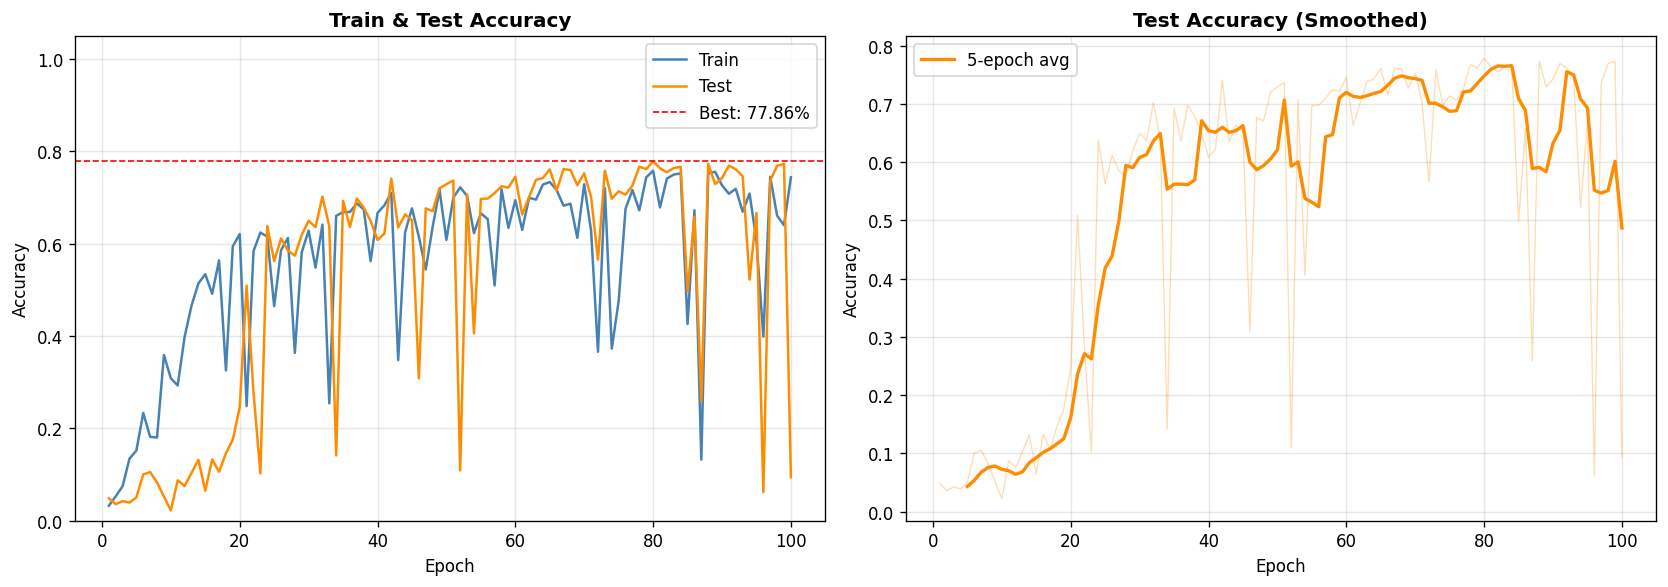

Saved: training_curves_v2.png

=== Evaluation ===
Best weights loaded
2328/2328 [==============================] - 48s 20ms/step

Overall Test Accuracy: 77.86%
Class            Prec      Rec       F1       N
------------------------------------------------
A001            0.764    0.769    0.767    1054
A002            0.739    0.698    0.718     814
A003            0.853    0.869    0.861    1398
A004            0.837    0.759    0.796     792
A005            0.891    0.866    0.878     528
A006            0.610    0.378    0.467     527
A007            0.546    0.217    0.311     520
A008            0.747    0.843    0.792     527
A009            0.665    0.462    0.545     528
A010            0.792    0.662    0.721     379
A011            0.544    0.082    0.142     526
A012            0.893    0.824    0.857     262
A013            0.844    0.703    0.767     424
A014            0.848    0.871    0.859     792
A015            0.733    0.856    0.790     792
A016            0.664  

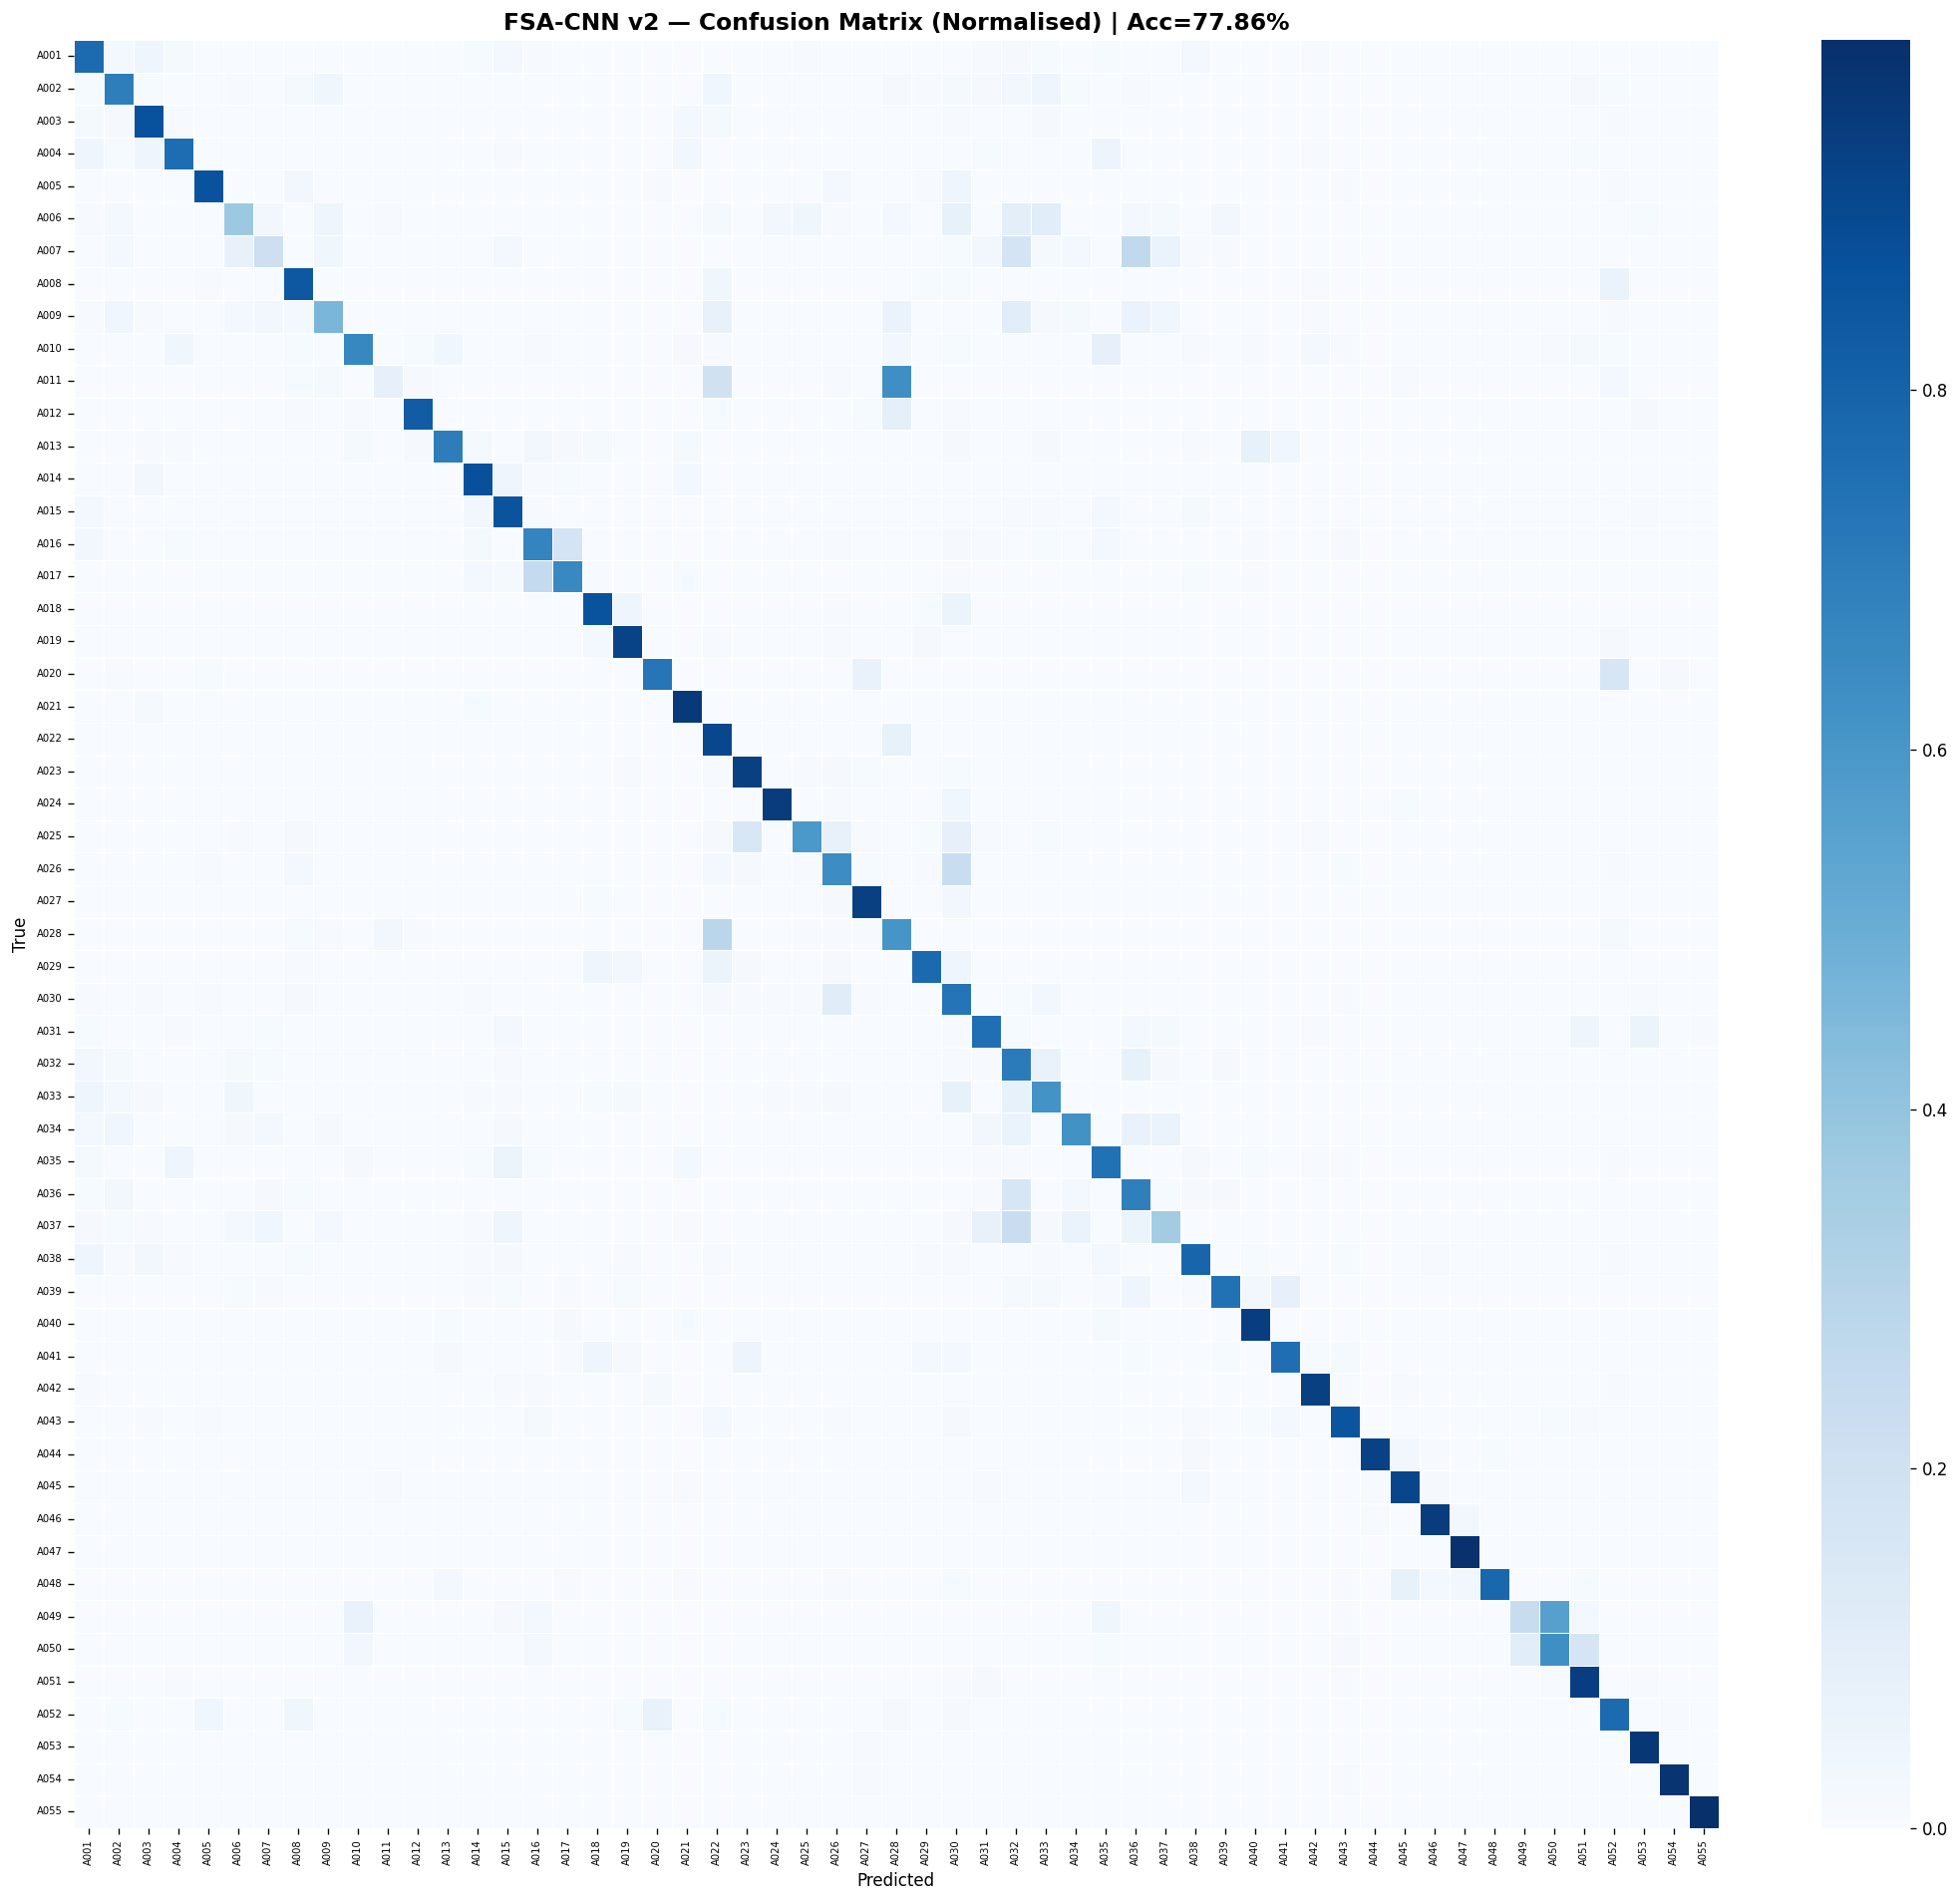

Saved: confusion_matrix_v2.png

Top 10 Confused Pairs:
  A011 → A028  63.1%
  A049 → A050  55.7%
  A028 → A022  28.7%
  A007 → A036  26.5%
  A017 → A016  25.5%
  A026 → A030  23.7%
  A037 → A032  23.1%
  A011 → A022  19.6%
  A016 → A017  17.8%
  A007 → A032  17.5%

=== TTA (10 passes) ===
  Run 1/10


InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [11]:
# # ── GPU memory clear before training ─────────────────────────────────────────
# clear_gpu_memory()

# # ── Configure experiment ─────────────────────────────────────────────────────
# config = FSACNNConfig()
# config.TRAIN_FROM_SCRATCH = True    # True = scratch | False = pretrained fine-tune
# config.RESUME_CHECKPOINT  = True    # resume from SAVE_LATEST if it exists
# config.RUN_EVAL           = True
# config.RUN_TTA            = True
# config.RUN_PLOTS          = True
# config._set_seeds()

# print('\n=== FSA-CNN v2 Configuration ===')
# print(f'Mode          : {"Scratch" if config.TRAIN_FROM_SCRATCH else "Pretrained"}')
# print(f'base_lr       : {config.lr}')
# print(f'LR warmup     : {config.LR_WARMUP_EPOCHS} epochs then cosine decay')
# print(f'Freeze warmup : {config.FREEZE_WARMUP_EPOCHS} epochs')
# print(f'Label smooth  : {config.LABEL_SMOOTHING}')
# print(f'Clip norm     : {config.CLIP_NORM}')
# print(f'Mixup alpha   : {config.MIXUP_ALPHA if config.AUGMENTATION_MIXUP else "OFF"}')
# print(f'Batch size    : {config.BATCH_SIZE}')
# print(f'Dropout head  : {config.DROPOUT_HEAD1}/{config.DROPOUT_HEAD2}/{config.DROPOUT_HEAD3}/{config.DROPOUT_HEAD4}')
# print(f'BatchNorm     : {config.USE_BN}')
# print()

# # ── Train ────────────────────────────────────────────────────────────────────
# trainer = FSACNNTrainer(config)
# trainer.train()

## 🔬 Standalone Evaluation
Run evaluation or TTA without retraining.

In [ ]:
# Standalone eval — no retraining needed
# # trainer.setup() must have been called (or trainer.train() completed)
# clear_gpu_memory()
# trainer.evaluate()
# trainer.run_tta()

# Pretrained fine-tune

In [ ]:
# clear_gpu_memory()

# config = FSACNNConfig()
# config.TRAIN_FROM_SCRATCH  = False
# config.RESUME_CHECKPOINT   = False   # start fresh from original pretrained weights
# config.EPOCHS              = 100
# config.LR_WARMUP_EPOCHS    = 5       # shorter warmup — weights already meaningful
# config.BATCH_SIZE          = 16
# config.USE_BN              = False   # ← must be False — pretrained h5 has no BN layers
# config.LABEL_SMOOTHING     = 0.1
# config.CLIP_NORM           = 0.5    # tighter — Taylor powers need this
# config.LAYER_THRESH        = 0.6    # was 0.8 — less aggressive freezing
# config.LR_MIN_FACTOR       = 0.05   # was 0.01 — don't let LR die completely
# config.LEARNING_RATE       = 5e-5   # fine-tune LR (pretrained weights are good, go slow)
# config.FREEZE_WARMUP_EPOCHS = 0      # pretrained weights can handle freezing from epoch 1
# config.RUN_EVAL            = True
# config.RUN_TTA             = True
# config.RUN_PLOTS           = True
# config.SAVE_BEST           = './Weight_pretrain_best.h5'
# config.SAVE_LATEST         = './Weight_pretrain_latest.h5'
# config._set_seeds()

# trainer_pretrain = FSACNNTrainer(config)
# trainer_pretrain.train()

GPU memory — used: 20710 MiB | free: 60329 MiB | total: 81920 MiB
Train: 75370 | Test: 37247
Loading test set...
37247 test samples | shape: (37247, 64, 31, 2)
Pretrained weights loaded: ./Explainable-Action-Recognition-for-Older-Adults-/AIR-Action-Recognition/TestBed_OpenPose_v4_COCO_6_9100.h5
Starting 100 epochs...

400/400 [==============================] - 52s 40ms/step - loss: 2.1140 - accuracy: 0.8831
Epoch 001/100 | lr=1.40e-05 | freeze=ON | Train=0.8831 | Test=0.8659 | Best=0.0000
  ★ New best: 0.8659 (86.59%)
400/400 [==============================] - 24s 35ms/step - loss: 1.2629 - accuracy: 0.9223
Epoch 002/100 | lr=2.30e-05 | freeze=ON | Train=0.9223 | Test=0.8736 | Best=0.8659
  ★ New best: 0.8736 (87.36%)
400/400 [==============================] - 24s 37ms/step - loss: 1.2441 - accuracy: 0.9227
Epoch 003/100 | lr=3.20e-05 | freeze=ON | Train=0.9227 | Test=0.8804 | Best=0.8736
  ★ New best: 0.8804 (88.04%)
400/400 [==============================] - 28s 40ms/step - loss: 1.1

## 🎬 Video Inference
Upload an MP4/AVI, run this cell. Saves annotated video with skeleton + predictions.

In [1]:
# pip install mediapipe==0.10.9 opencv-python==4.8.1.78 --only-binary=:all: --break-system-packages

  Using cached mediapipe-0.10.9-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.6 kB)
  Using cached opencv_python-4.8.1.78-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
  Using cached sounddevice-0.5.5-py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 73.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 89.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 MB 50.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 72.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.21.12
    Uninstalling protobuf-4.21.12:
      Successfully uninstalled protobuf-4.21.1

In [9]:
# ── MediaPipe → ETRI joint mapping ────────────────────────────────────────────
# neck (-1) = average of L_shoulder(11) + R_shoulder(12)
MP_TO_ETRI = [0,-1,12,14,16,11,13,15,24,26,28,23,25,27,5,2,8,7]

ETRI_LABELS = [
    "Walking","Running","Jumping","Sitting down","Standing up",
    "Lying down","Getting up","Bending","Picking up","Putting down",
    "Pushing","Pulling","Carrying","Throwing","Catching",
    "Waving","Clapping","Pointing","Shaking hands","Hugging",
    "Eating","Drinking","Pouring","Cooking","Washing hands",
    "Washing face","Brushing teeth","Combing hair","Dressing","Using phone",
    "Reading","Writing","Typing","Watching TV","Using computer",
    "Playing instrument","Exercising","Stretching","Sweeping","Mopping",
    "Vacuuming","Doing laundry","Ironing","Folding clothes","Making bed",
    "Washing dishes","Chopping","Stirring","Opening door","Closing door",
    "Opening drawer","Closing drawer","Opening fridge","Closing fridge","Falling",
]

SKEL_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),
    (1,8),(8,9),(9,10),(1,11),(11,12),(12,13),
    (0,14),(0,15),(14,16),(15,17)
]

class FSACNNInference:
    """
    Run FSA-CNN on an MP4/AVI video.
    Uses the model already defined in this notebook — no rebuild needed.

    Usage:
        inf = FSACNNInference(config)
        inf.load_weights('./Weight_pretrain_best.h5')   # or scratch best
        inf.run('my_video.mp4')
        # output: my_video_annotated.mp4  +  my_video_results.txt
    """

    def __init__(self, config: FSACNNConfig):
        self.cfg     = config
        self.model   = None
        self.STRIDE  = 8    # run prediction every N frames (~4x/sec at 30fps)
        self.TOP_K   = 3

    def load_weights(self, weights_path: str):
        """Build model from config and load weights."""
        print(f'Building model (BN={self.cfg.USE_BN})...')
        self.model = FSACNNModel(self.cfg).build()
        self.model.load_weights(weights_path)
        self.model.compile(optimizer=Adam(self.cfg.lr),
                           loss='categorical_crossentropy', metrics=['accuracy'])
        print(f'Weights loaded: {weights_path}')
        print(f'Parameters: {self.model.count_params():,}')

    # ── Skeleton helpers ──────────────────────────────────────────────────────
    def _extract_joints(self, frame, pose):
        """MediaPipe → 18 ETRI joints in pixel coords. Returns (18,2) or None."""
        import mediapipe as mp
        h, w = frame.shape[:2]
        rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res  = pose.process(rgb)
        if not res.pose_landmarks:
            return None
        lm = res.pose_landmarks.landmark
        joints = np.zeros((18,2), dtype='float32')
        for i, mp_idx in enumerate(MP_TO_ETRI):
            if mp_idx == -1:
                joints[i] = [(lm[11].x+lm[12].x)/2*w, (lm[11].y+lm[12].y)/2*h]
            else:
                joints[i] = [lm[mp_idx].x*w, lm[mp_idx].y*h]
        return joints

    def _preprocess_buffer(self, buffer):
        """buffer: list of FRAMES (18,2) arrays → 8 model input streams."""
        cfg = self.cfg
        s0  = np.array(buffer, dtype='float32')[np.newaxis]  # (1,64,18,2)
        s1  = s0.copy()
        mid = cfg.FRAMES // 2
        # Centre
        rx = s0[:,mid:mid+1,0:1,0:1]; ry = s0[:,mid:mid+1,0:1,1:2]
        s0[:,:,:,0:1] -= np.tile(rx,(1,cfg.FRAMES,18,1))
        s0[:,:,:,1:2] -= np.tile(ry,(1,cfg.FRAMES,18,1))
        s1[:,:,:,0:1] -= np.tile(rx,(1,cfg.FRAMES,18,1))
        s1[:,:,:,1:2] -= np.tile(ry,(1,cfg.FRAMES,18,1))
        # Torso scale
        def _b(s,j1,j2):
            return np.sqrt(
                (s[:,mid:mid+1,j1:j1+1,0:1]-s[:,mid:mid+1,j2:j2+1,0:1])**2+
                (s[:,mid:mid+1,j1:j1+1,1:2]-s[:,mid:mid+1,j2:j2+1,1:2])**2)
        torso = _b(s0,0,1)+_b(s0,1,2)+_b(s0,2,3)
        torso = np.tile(torso,(1,cfg.FRAMES,18,2))+1e-4
        s0 /= torso; s1 /= torso
        # Streams
        u0  = s0[:,:,cfg.JOINT_REINDEX,:]
        u1  = s1[:,:,cfg.JOINT_REINDEX,:]
        nj  = len(cfg.JOINT_REINDEX)
        zp  = np.zeros((1,1,nj,2),'float32')
        zpl = np.tile(zp,(1,cfg.LONG_TERM,1,1))
        d0  = np.append(np.diff(u0,n=1,axis=1), zp,  axis=1).astype('float32')
        d1  = np.append(np.diff(u1,n=1,axis=1), zp,  axis=1).astype('float32')
        d02 = np.append(np.diff(u0,n=cfg.LONG_TERM,axis=1),zpl,axis=1).astype('float32')
        d12 = np.append(np.diff(u1,n=cfg.LONG_TERM,axis=1),zpl,axis=1).astype('float32')
        d2  = np.diff(u0,n=1,axis=2).astype('float32')
        d3  = np.diff(u1,n=1,axis=2).astype('float32')
        return [u0.astype('float32'),u1.astype('float32'),d0,d1,d02,d12,d2,d3]

    # ── Drawing helpers ───────────────────────────────────────────────────────
    def _draw_skeleton(self, frame, joints):
        for j1,j2 in SKEL_CONNECTIONS:
            p1 = tuple(joints[j1].astype(int))
            p2 = tuple(joints[j2].astype(int))
            cv2.line(frame, p1, p2, (0,255,0), 2)
        for pt in joints:
            cv2.circle(frame, tuple(pt.astype(int)), 4, (0,0,255), -1)

    def _draw_overlay(self, frame, labels, probs, fidx, total):
        h, w = frame.shape[:2]
        # Semi-transparent panel
        panel = frame.copy()
        cv2.rectangle(panel, (10,10), (390,140), (0,0,0), -1)
        cv2.addWeighted(panel, 0.55, frame, 0.45, 0, frame)
        # Title
        cv2.putText(frame,'FSA-CNN Action Recognition',(15,32),
                    cv2.FONT_HERSHEY_SIMPLEX,0.58,(255,255,255),1,cv2.LINE_AA)
        # Top-3 bars
        colors = [(0,255,100),(0,220,255),(0,160,220)]
        for rank,(lbl,prob) in enumerate(zip(labels,probs)):
            y = 52 + rank*28
            cv2.rectangle(frame,(15,y),(15+int(prob*280),y+18),colors[rank],-1)
            cv2.putText(frame,f'{lbl[:24]:<24} {prob*100:5.1f}%',(16,y+14),
                        cv2.FONT_HERSHEY_SIMPLEX,0.40,(255,255,255),1,cv2.LINE_AA)
        # Frame counter bottom right
        cv2.putText(frame,f'Frame {fidx}/{total}',(w-170,h-12),
                    cv2.FONT_HERSHEY_SIMPLEX,0.42,(180,180,180),1,cv2.LINE_AA)

    # ── Main run ──────────────────────────────────────────────────────────────
    def run(self, video_path: str, output_path: str = None):
        """
        Process video_path, write annotated output.
        output_path defaults to <name>_annotated.mp4 in same folder.
        """
        import mediapipe as mp_lib

        if self.model is None:
            raise RuntimeError('Call load_weights() before run()')
        cfg = self.cfg

        # ── Open video ────────────────────────────────────────────────────
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise FileNotFoundError(f'Cannot open: {video_path}')
        fps     = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        vid_w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        vid_h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        print(f'Video: {vid_w}x{vid_h} @ {fps:.1f}fps  |  {total_f} frames')

        # ── Output writer ─────────────────────────────────────────────────
        if output_path is None:
            base = os.path.splitext(video_path)[0]
            output_path = f'{base}_annotated.mp4'
        log_path = output_path.replace('_annotated.mp4','_results.txt')
        writer   = cv2.VideoWriter(output_path,
                                   cv2.VideoWriter_fourcc(*'mp4v'),
                                   fps, (vid_w,vid_h))

        # ── Pose estimator ────────────────────────────────────────────────
        pose = mp_lib.solutions.pose.Pose(
            static_image_mode=False, model_complexity=1,
            smooth_landmarks=True,
            min_detection_confidence=0.5, min_tracking_confidence=0.5)

        skel_buf   = []
        last_jts   = np.zeros((18,2),'float32')
        last_top3  = (['Detecting...','',''], [0.,0.,0.])
        log_lines  = [f'FSA-CNN Inference | {video_path}',
                      f'Weights: {cfg.SAVE_BEST}', '='*55]
        stride     = max(1, int(fps // 4))   # 4 predictions/sec

        print(f'Running inference (predict every {stride} frames)...')

        fidx = 0
        while True:
            ret, frame = cap.read()
            if not ret: break
            fidx += 1

            # Pose
            jts = self._extract_joints(frame, pose)
            if jts is None: jts = last_jts.copy()
            else:           last_jts = jts.copy()

            skel_buf.append(jts.copy())
            if len(skel_buf) > cfg.FRAMES:
                skel_buf.pop(0)

            # Predict
            if len(skel_buf) == cfg.FRAMES and fidx % stride == 0:
                streams  = self._preprocess_buffer(list(skel_buf))
                probs    = self.model.predict(streams, verbose=0)[0]
                top_idx  = np.argsort(probs)[::-1][:self.TOP_K]
                labels   = [ETRI_LABELS[i] for i in top_idx]
                scores   = [float(probs[i])  for i in top_idx]
                last_top3 = (labels, scores)
                log_lines.append(
                    f'Frame {fidx:05d} | {labels[0]} {scores[0]*100:.1f}% | '
                    f'{labels[1]} {scores[1]*100:.1f}% | '
                    f'{labels[2]} {scores[2]*100:.1f}%')
                if fidx % (stride*20) == 0:
                    pct = fidx/total_f*100
                    print(f'  {pct:5.1f}%  [{fidx}/{total_f}]  → {labels[0]} ({scores[0]*100:.1f}%)')

            # Draw
            self._draw_skeleton(frame, last_jts)
            self._draw_overlay(frame, last_top3[0], last_top3[1], fidx, total_f)
            writer.write(frame)

        cap.release(); writer.release(); pose.close()

        with open(log_path,'w') as f: f.write('\n'.join(log_lines))

        print(f'\n✓ Done!')
        print(f'  Output video : {output_path}')
        print(f'  Results log  : {log_path}')

        # Summary
        preds = [l.split(' | ')[1].split(' ')[0] for l in log_lines if l.startswith('Frame')]
        if preds:
            from collections import Counter
            print('\n  Most predicted actions:')
            for lbl,cnt in Counter(preds).most_common(5):
                print(f'    {lbl:<28} {cnt:>4}x  ({cnt/len(preds)*100:.0f}%)')

        return output_path

print('FSACNNInference class defined')
print()
print('Usage:')
print('  import cv2')
print('  inf = FSACNNInference(config)')
print('  inf.load_weights(\'./Weight_pretrain_best.h5\')')
print('  inf.run(\'my_video.mp4\')')

FSACNNInference class defined

Usage:
  import cv2
  inf = FSACNNInference(config)
  inf.load_weights('./Weight_pretrain_best.h5')
  inf.run('my_video.mp4')


In [10]:
# import cv2   # pip install opencv-python --break-system-packages
#              # pip install mediapipe        --break-system-packages

# # ── Edit these two lines ──────────────────────────────────────────────────────
# VIDEO_PATH   = './my_video.mp4'           # ← your video
# WEIGHTS_PATH = './Weight_pretrain_best.h5'  # ← pretrained best (USE_BN=False)
#                                             #   or Weight_scratch_best.h5 (USE_BN=True)

# # ── Config must match the weights you're loading ──────────────────────────────
# inf_config          = FSACNNConfig()
# inf_config.USE_BN   = False   # False = pretrained weights | True = scratch v2 weights
# inf_config.SAVE_BEST = WEIGHTS_PATH

# inf = FSACNNInference(inf_config)
# inf.load_weights(WEIGHTS_PATH)
# inf.run(VIDEO_PATH)

Building model (BN=False)...
Weights loaded: ./Weight_pretrain_best.h5
Parameters: 2,760,711
Video: 1920x1080 @ 30.0fps  |  320 frames


I0000 00:00:1773138648.943058   23403 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773138649.032943   23851 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.90.07), renderer: Tesla P100-SXM2-16GB/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Running inference (predict every 7 frames)...
   43.8%  [140/320]  → Chopping (24.8%)
   87.5%  [280/320]  → Watching TV (26.8%)

✓ Done!
  Output video : ./my_video_annotated.mp4
  Results log  : ./my_video_results.txt

  Most predicted actions:
    Watching                       10x  (28%)
    Chopping                        9x  (25%)
    Shaking                         8x  (22%)
    Eating                          3x  (8%)
    Making                          2x  (6%)


'./my_video_annotated.mp4'